# Генерация синтетических данных с использованием Faker

In [1]:
!pip install faker


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import random
from faker import Faker
from datetime import datetime, timedelta

In [3]:
# Инициализация генератора (русская локаль для реалистичных ФИО, адресов и т.д.)
fake = Faker('ru_RU')
Faker.seed(42)      # фиксируем seed для воспроизводимости
random.seed(42)

## Генерация синтетических данных для варианта "Сотрудники компании"

In [4]:
# DataFrame с отделами
def generate_departments(n):
   
    departments = []
    for i in range(1, n + 1):
        departments.append({
            'department_id': i,
            'name': fake.unique.job() + ' отдел',  # уникальное название
            'location': fake.city()
        })
    return pd.DataFrame(departments)

# DataFrame с должностями и диапазоном зарплат
def generate_positions(n: int) -> pd.DataFrame:
    
    positions = []
    for i in range(1, n + 1):
        min_salary = random.randint(30000, 60000)
        max_salary = min_salary + random.randint(20000, 80000)
        positions.append({
            'position_id': i,
            'name': fake.unique.job(),
            'min_salary': min_salary,
            'max_salary': max_salary
        })
    return pd.DataFrame(positions)

# генерируем сотрудников со случайными атрибутами
def generate_employees(n: int, department_ids: list, position_ids: list) -> pd.DataFrame:
    
    employees = []
    for emp_id in range(1, n + 1):        
        first_name = fake.first_name()
        last_name = fake.last_name()
        patronymic = fake.middle_name()
        birth_date = fake.date_of_birth(minimum_age=18, maximum_age=70)
        phone = fake.phone_number()
        email = fake.email()
        address = fake.address().replace('\n', ', ')
        
        # дата найма: не раньше 18-летия и не позже сегодняшнего дня
        min_hire_date = birth_date + timedelta(days=18*365)
        hire_date = fake.date_between(start_date=min_hire_date, end_date='today')
        
        # статус -  active / terminated (10% уволены)
        status = random.choices(['active', 'terminated'], weights=[0.9, 0.1])[0]
        
        # выбор отдела и должности
        department_id = random.choice(department_ids)
        position_id = random.choice(position_ids)
        
        # зарплата     
        salary = random.randint(40000, 150000)
        
        employees.append({
            'employee_id': emp_id,
            'last_name': last_name,
            'first_name': first_name,
            'patronymic': patronymic,
            'birth_date': birth_date,
            'gender': random.choice(['М', 'Ж']),
            'address': address,
            'phone': phone,
            'email': email,
            'hire_date': hire_date,
            'status': status,
            'department_id': department_id,
            'position_id': position_id,
            'salary': salary
        })
    return pd.DataFrame(employees)

# создать историю зарплат на основе данных сотрудников
def generate_salary_history(employees_df: pd.DataFrame, avg_records: int = 3):    
    history = []
    record_id = 1
    
    for _, emp in employees_df.iterrows():
        emp_id = emp['employee_id']
        hire_date = emp['hire_date']
        current_salary = emp['salary']
        
        # количество изменений (0 – если сотрудник только нанят и ещё не было изменений)
        num_changes = random.choices([0, 1, 2, 3, 4], weights=[0.2, 0.3, 0.3, 0.1, 0.1])[0]
        
        # генерируем даты изменений (после hire_date и до сегодня)
        change_dates = sorted([fake.date_between(start_date=hire_date, end_date='today') 
                               for _ in range(num_changes)])
        
        # начальная зарплата при найме (можно сделать немного отличающейся от текущей)
        #  будем считать, что первая запись – это зарплата при найме,
        # а последующие – повышения.
        if num_changes == 0:
            # Если изменений не было, всё равно добавим одну запись (начальная)
            history.append({
                'history_id': record_id,
                'employee_id': emp_id,
                'change_date': hire_date,
                'new_salary': current_salary
            })
            record_id += 1
        else:
            # генерируем возрастающие зарплаты
            salary_values = sorted([random.randint(30000, current_salary) for _ in range(num_changes)])
            # добавляем текущую зарплату как последнюю
            salary_values.append(current_salary)
            # даты: hire_date и change_dates
            all_dates = [hire_date] + change_dates
            for i in range(len(all_dates)):
                history.append({
                    'history_id': record_id,
                    'employee_id': emp_id,
                    'change_date': all_dates[i],
                    'new_salary': salary_values[i]
                })
                record_id += 1
    return pd.DataFrame(history)

In [5]:
N_DEPARTMENTS = 10
N_POSITIONS = 20
N_EMPLOYEES = 500

In [6]:
departments_df = generate_departments(N_DEPARTMENTS)
positions_df = generate_positions(N_POSITIONS)
employees_df = generate_employees(
    N_EMPLOYEES,
    departments_df['department_id'].tolist(),
    positions_df['position_id'].tolist()
)

In [7]:
departments_df

,department_id,name,location
0,1,Дефектолог отдел,клх Кырен
1,2,Машинистка отдел,п. Волоколамск
2,3,Географ отдел,г. Артем
3,4,Гирудотерапевт отдел,п. Териберка
4,5,Бактериолог отдел,клх Усинск
5,6,Стоматолог отдел,с. Чикола
6,7,Нарколог отдел,ст. Ессентуки
7,8,Стрелочник отдел,к. Ельня
8,9,Крупье отдел,г. Видное
9,10,Рефлексотерапевт отдел,к. Нефедова


In [8]:
positions_df

,position_id,name,min_salary,max_salary
0,1,Модельер,50952,78248
1,2,Борт-радист,30819,99417
2,3,Травматолог,39012,75061
3,4,Диспетчер,37314,66458
4,5,Рентгенолог,54132,80849
5,6,Врач МСЭК,52174,120714
6,7,Оперативный работник,59234,114975
7,8,Радиолог,32848,91546
8,9,Кодер,43825,65907
9,10,Военный полицейский,30976,57116


In [9]:
employees_df

,employee_id,last_name,first_name,patronymic,birth_date,gender,address,phone,email,hire_date,status,department_id,position_id,salary
0,1,Гаврилов,Мина,Кузьминична,1973-04-17,М,"к. Бологое, пер. Островского, д. 77, 242388",+7 928 327 64 83,tatjana_03@example.org,2009-02-27,active,7,11,76421
1,2,Григорьева,Ольга,Федотович,1994-11-01,Ж,"д. Красногорск (Моск.), ш. Заречное, д. 684 ст...",8 532 871 01 22,erjabova@example.com,2023-06-17,active,6,4,52156
2,3,Крюкова,Лаврентий,Егоровна,1989-09-03,М,"п. Хасавюрт, ул. Вахитова, д. 382, 824896",83252880957,makarovamaja@example.com,2014-11-13,active,6,20,74671
3,4,Лукина,Тимур,Николаевна,2002-01-26,М,"г. Яхрома, алл. Профсоюзная, д. 951, 473829",+7 (465) 787-1331,adrian_98@example.org,2024-12-16,active,9,4,89615
4,5,Мартынов,Савватий,Станиславовна,1987-04-24,М,"п. Уварово, алл. Челюскинцев, д. 84 к. 81, 080132",8 311 656 67 01,maslovalukija@example.org,2019-02-15,active,10,12,115674
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,496,Фомина,Амвросий,Валерьевич,1966-07-21,Ж,"клх Котельнич, алл. Угольная, д. 4/4 стр. 356,...",+78255442867,ikarpov@example.com,1996-08-23,active,4,16,112173
496,497,Гуляев,Мефодий,Владленович,1994-04-14,М,"к. Ардон, пр. Механический, д. 9/6 стр. 895, 4...",+7 (693) 358-95-13,vatslav_2008@example.net,2014-04-24,active,8,16,100401
497,498,Корнилова,Евдокия,Якубович,1994-05-22,Ж,"п. Партизанск, ул. 40 лет Победы, д. 8 к. 455,...",+7 179 720 38 59,karpevseev@example.org,2020-06-20,active,6,6,58344
498,499,Терентьева,Милица,Андреевна,1961-10-02,М,"д. Тура, бул. Советской Армии, д. 892, 452388",+7 (675) 009-4214,petrovmina@example.org,2017-09-12,active,9,2,108674


In [10]:
# Генерация истории зарплат
salary_history_df = generate_salary_history(employees_df, avg_records=3)
salary_history_df

,history_id,employee_id,change_date,new_salary
0,1,1,2009-02-27,71333
1,2,1,2022-12-24,76421
2,3,2,2023-06-17,34948
3,4,2,2025-04-12,52156
4,5,3,2014-11-13,74671
...,...,...,...,...
1291,1292,498,2021-09-18,57426
1292,1293,498,2024-04-13,58344
1293,1294,499,2017-09-12,89827
1294,1295,499,2018-05-29,108674


In [11]:
# Сохранение в CSV
departments_df.to_csv('departments.csv', index=False)
positions_df.to_csv('positions.csv', index=False)
employees_df.to_csv('employees.csv', index=False)
salary_history_df.to_csv('salary_history.csv', index=False)

# Задание на самостоятельную работу
Создать синтетический набор данных, сохранить его в csv файлы, построить на основе данных онтологию, вывести онтограф.



### Вариант 2. Банковские клиенты и транзакции
Сущности: 
- Клиент: id, ФИО, дата рождения, паспортные данные (серия, номер, кем выдан), адрес, телефон, email.
- Счёт: id, номер счёта, тип (дебетовый/кредитный), валюта, дата открытия, остаток, id клиента.
- Транзакция: id, дата, сумма, тип (пополнение/списание), id счёта, описание.
- Кредит: id, id клиента, сумма, процентная ставка, срок, дата выдачи, ежемесячный платёж.

Объём: 1000 клиентов, у каждого 1–3 счёта, на каждом 10–50 транзакций, 20% клиентов имеют кредиты.

Онтология:
- Классы: Клиент, Счёт, Транзакция, Кредит.
- Связи: клиент владеет счетами, по счетам проходят транзакции, клиент может иметь кредиты.


In [3]:
import pandas as pd
import random
from faker import Faker
from datetime import datetime, timedelta

# Инициализация генератора
fake = Faker('ru_RU')
Faker.seed(42)
random.seed(42)

# --- 1. Генерация клиентов ---
def generate_clients(n: int) -> pd.DataFrame:
    clients = []
    for i in range(1, n + 1):
        # Генерируем дату рождения (от 18 до 80 лет)
        birth_date = fake.date_of_birth(minimum_age=18, maximum_age=80)
        
        clients.append({
            'client_id': i,
            'last_name': fake.last_name(),
            'first_name': fake.first_name(),
            'patronymic': fake.middle_name(),
            'birth_date': birth_date,
            'passport_series': f"{random.randint(10, 99)}{random.randint(10, 99)}",
            'passport_number': str(random.randint(100000, 999999)),
            'passport_issued_by': f"ГУ МВД России по {fake.region()}",
            'address': fake.address().replace('\n', ', '),
            'phone': fake.phone_number(),
            'email': fake.email()
        })
    return pd.DataFrame(clients)

# --- 2. Генерация счетов ---
def generate_accounts(clients_df: pd.DataFrame) -> pd.DataFrame:
    accounts = []
    acc_id = 1
    
    for _, client in clients_df.iterrows():
        # От 1 до 3 счетов на клиента
        num_accounts = random.randint(1, 3)
        client_id = client['client_id']
        birth_date = client['birth_date']
        
        # Счёт может быть открыт не раньше 18-летия
        min_open_date = birth_date + timedelta(days=18*365)
        
        for _ in range(num_accounts):
            open_date = fake.date_between(start_date=min_open_date, end_date='today')
            
            accounts.append({
                'account_id': acc_id,
                'account_number': fake.bban(), # Генерация номера счета
                'account_type': random.choice(['дебетовый', 'кредитный']),
                'currency': random.choices(['RUB', 'USD', 'EUR'], weights=[0.85, 0.1, 0.05])[0],
                'open_date': open_date,
                'balance': round(random.uniform(0.0, 1500000.0), 2),
                'client_id': client_id
            })
            acc_id += 1
            
    return pd.DataFrame(accounts)

# --- 3. Генерация транзакций ---
def generate_transactions(accounts_df: pd.DataFrame) -> pd.DataFrame:
    transactions = []
    trans_id = 1
    
    # Шаблоны описаний для реалистичности
    descriptions = {
        'пополнение': ['Зарплата', 'Внесение наличных через банкомат', 'Входящий перевод', 'Кэшбэк', 'Возврат средств'],
        'списание': ['Оплата в супермаркете', 'Перевод клиенту', 'Оплата ЖКУ', 'Снятие наличных', 'Оплата подписки', 'Покупка в интернете']
    }
    
    for _, acc in accounts_df.iterrows():
        # От 10 до 50 транзакций на каждый счет
        num_trans = random.randint(10, 50)
        acc_id = acc['account_id']
        open_date = acc['open_date']
        
        for _ in range(num_trans):
            # Транзакция не может быть раньше открытия счёта
            trans_date = fake.date_between(start_date=open_date, end_date='today')
            trans_type = random.choices(['пополнение', 'списание'], weights=[0.3, 0.7])[0]
            desc = random.choice(descriptions[trans_type])
            
            transactions.append({
                'transaction_id': trans_id,
                'transaction_date': trans_date,
                'amount': round(random.uniform(100.0, 150000.0), 2),
                'transaction_type': trans_type,
                'account_id': acc_id,
                'description': desc
            })
            trans_id += 1
            
    return pd.DataFrame(transactions)

# --- 4. Генерация кредитов ---
def generate_credits(clients_df: pd.DataFrame) -> pd.DataFrame:
    credits = []
    credit_id = 1
    
    # Ровно 20% клиентов имеют кредиты
    num_clients_with_credit = int(len(clients_df) * 0.2)
    selected_clients = clients_df.sample(n=num_clients_with_credit, random_state=42)
    
    for _, client in selected_clients.iterrows():
        client_id = client['client_id']
        birth_date = client['birth_date']
        min_issue_date = birth_date + timedelta(days=18*365)
        
        issue_date = fake.date_between(start_date=min_issue_date, end_date='today')
        amount = random.randint(50000, 5000000)
        interest_rate = round(random.uniform(9.0, 25.0), 1)
        term_months = random.choice([6, 12, 24, 36, 60, 120, 360]) # срок в месяцах
        
        # Простой расчет аннуитетного платежа
        monthly_rate = interest_rate / 12 / 100
        annuity_factor = (monthly_rate * (1 + monthly_rate)**term_months) / ((1 + monthly_rate)**term_months - 1)
        monthly_payment = round(amount * annuity_factor, 2)
        
        credits.append({
            'credit_id': credit_id,
            'client_id': client_id,
            'amount': amount,
            'interest_rate': interest_rate,
            'term_months': term_months,
            'issue_date': issue_date,
            'monthly_payment': monthly_payment
        })
        credit_id += 1
        
    return pd.DataFrame(credits)


N_CLIENTS = 1000


clients_df = generate_clients(N_CLIENTS)


accounts_df = generate_accounts(clients_df)

transactions_df = generate_transactions(accounts_df)

print("Генерация кредитов...")
credits_df = generate_credits(clients_df)

print("\n Сводка по данным")
print(f"Клиентов: {len(clients_df)}")
print(f"Счетов: {len(accounts_df)}")
print(f"Транзакций: {len(transactions_df)}")
print(f"Кредитов: {len(credits_df)}")

# Сохранение в CSV-файлы
clients_df.to_csv('clients.csv', index=False)
accounts_df.to_csv('accounts.csv', index=False)
transactions_df.to_csv('transactions.csv', index=False)
credits_df.to_csv('credits.csv', index=False)



Генерация кредитов...

 Сводка по данным
Клиентов: 1000
Счетов: 2012
Транзакций: 61377
Кредитов: 200


In [4]:
from owlready2 import *
import pandas as pd


onto = get_ontology("http://example.org/bank_ontology_ru.owl")

with onto:
    # Базовые классы (сущности)
    class Клиент(Thing):
        pass

    class Счет(Thing):
        pass

    class Транзакция(Thing):
        pass

    class Кредит(Thing):
        pass
    #  Определяем связи (ObjectProperty) 
    
    class владеет_счетом(ObjectProperty):
        domain    = [Клиент]
        range     = [Счет]

    class имеет_кредит(ObjectProperty):
        domain    = [Клиент]
        range     = [Кредит]

    class относится_к_счету(ObjectProperty):
        domain    = [Транзакция]
        range     = [Счет]


    #  Атрибуты (DataProperty) 
    
    # Для Клиента
    class фио(DataProperty):
        domain = [Клиент]; range = [str]
    class дата_рождения(DataProperty):
        domain = [Клиент]; range = [str]
    class паспортные_данные(DataProperty):
        domain = [Клиент]; range = [str]
    class адрес(DataProperty):
        domain = [Клиент]; range = [str]
    class телефон(DataProperty):
        domain = [Клиент]; range = [str]
    class email(DataProperty):
        domain = [Клиент]; range = [str]

    # Для Счета
    class номер_счета(DataProperty):
        domain = [Счет]; range = [str]
    class тип_счета(DataProperty):
        domain = [Счет]; range = [str]
    class валюта(DataProperty):
        domain = [Счет]; range = [str]
    class дата_открытия(DataProperty):
        domain = [Счет]; range = [str]
    class остаток(DataProperty):
        domain = [Счет]; range = [float] 

    # Для Транзакции
    class дата_транзакции(DataProperty):
        domain = [Транзакция]; range = [str]
    class сумма_транзакции(DataProperty):
        domain = [Транзакция]; range = [float]
    class тип_транзакции(DataProperty):
        domain = [Транзакция]; range = [str] 
    class описание(DataProperty):
        domain = [Транзакция]; range = [str]

    # Для Кредита
    class сумма_кредита(DataProperty):
        domain = [Кредит]; range = [float]
    class процентная_ставка(DataProperty):
        domain = [Кредит]; range = [float]
    class срок_в_месяцах(DataProperty):
        domain = [Кредит]; range = [int] 
    class дата_выдачи(DataProperty):
        domain = [Кредит]; range = [str]
    class ежемесячный_платеж(DataProperty):
        domain = [Кредит]; range = [float]

# Сохранение структуры онтологии в файл 
onto.save("bank_ontology.owl")

In [7]:

клиенты_инстансы = {}
счета_инстансы = {}

with onto:
    # Заполняем клиентов 
    for _, row in clients_df.iterrows():
        человек = Клиент(f"Клиент_{row['client_id']}")
        
        
        полное_фио = f"{row['last_name']} {row['first_name']} {row['patronymic']}"
        паспорт = f"{row['passport_series']} {row['passport_number']}"
        
        человек.фио = [полное_фио]
        человек.дата_рождения = [str(row['birth_date'])]
        человек.паспортные_данные = [паспорт]
        человек.адрес = [row['address']]
        человек.телефон = [row['phone']]
        человек.email = [row['email']]
        
        # Сохраняем в словарь по ID для будущих связей
        клиенты_инстансы[row['client_id']] = человек

    #  Заполняем банковские счета 
    for _, row in accounts_df.iterrows():
        счет = Счет(f"Счет_{row['account_id']}")
        счет.номер_счета = [row['account_number']]
        счет.тип_счета = [row['account_type']]
        счет.валюта = [row['currency']]
        счет.дата_открытия = [str(row['open_date'])]
        счет.остаток = [float(row['balance'])]
        
        # Связь с клиентом (владельцем)
        владелец = клиенты_инстансы.get(row['client_id'])
        if владелец:
            владелец.владеет_счетом.append(счет)
            
        счета_инстансы[row['account_id']] = счет

    #  Заполняем транзакции 
    for _, row in transactions_df.iterrows():
        операция = Транзакция(f"Транзакция_{row['transaction_id']}")
        операция.дата_транзакции = [str(row['transaction_date'])]
        операция.сумма_транзакции = [float(row['amount'])]
        операция.тип_транзакции = [row['transaction_type']]
        операция.описание = [row['description']]
        
        # Привязка транзакции к конкретному счету
        счет_привязки = счета_инстансы.get(row['account_id'])
        if счет_привязки:
            операция.относится_к_счету = [счет_привязки]

    # Заполняем кредиты 
    for _, row in credits_df.iterrows():
        договор = Кредит(f"Кредит_{row['credit_id']}")
        договор.сумма_кредита = [float(row['amount'])]
        договор.процентная_ставка = [float(row['interest_rate'])]
        договор.срок_в_месяцах = [int(row['term_months'])]
        договор.дата_выдачи = [str(row['issue_date'])]
        договор.ежемесячный_платеж = [float(row['monthly_payment'])]
        
        # Привязка кредита к клиенту
        заемщик = клиенты_инстансы.get(row['client_id'])
        if заемщик:
            заемщик.имеет_кредит.append(договор)

# Сохранение итоговой заполненной онтологии
onto.save("bank_ontology_.owl")


In [8]:
def print_bank_mindmap():
    print("\n" + "="*50)
    print("="*50)
    
    # Берем первых 5 клиентов для проверки
    for client in list(onto.Клиент.instances())[:5]:
        client_name = client.фио[0]
        print(f"\nКлиент: {client_name}")
        
        # Получаем список счетов клиента
        accounts = list(client.владеет_счетом)
        
        if not accounts:
            print("  Счета: нет")
        else:
            for account in accounts:
                acc_num = account.номер_счета[0]
                acc_type = account.тип_счета[0]
                balance = account.остаток[0]
                currency = account.валюта[0]
                
                print(f"  Счет: {acc_num} ({acc_type}) | Остаток: {balance} {currency}")
                
                # Ищем транзакции, которые относятся к этому счету
                transactions = [t for t in onto.Транзакция.instances() if account in t.относится_к_счету]
                
                if transactions:
                    print("    Транзакции (показаны первые 3):")
                    # Выводим только 3, чтобы не засорять консоль
                    for trans in transactions[:3]:
                        t_type = trans.тип_транзакции[0]
                        t_amount = trans.сумма_транзакции[0]
                        t_date = trans.дата_транзакции[0]
                        print(f"      - {t_date} | {t_type.capitalize()}: {t_amount} {currency}")
                else:
                    print("    Транзакции: нет")
                    
        # Ищем кредиты клиента
        credits = list(client.имеет_кредит)
        if credits:
            print("  Кредиты:")
            for credit in credits:
                c_amount = credit.сумма_кредита[0]
                c_rate = credit.процентная_ставка[0]
                c_payment = credit.ежемесячный_платеж[0]
                print(f"    - Сумма: {c_amount} руб. | Ставка: {c_rate}% | Платеж: {c_payment} руб./мес.")
        else:
            print("  Кредиты: нет")

# Запускаем вывод
print_bank_mindmap()



Клиент: Цветков Аким Павловна
  Счет: NMLX0285915658179 (дебетовый) | Остаток: 214890.65 RUB
    Транзакции (показаны первые 3):
      - 2020-10-05 | Списание: 24911.18 RUB
      - 2016-08-20 | Списание: 84418.54 RUB
      - 2022-10-24 | Списание: 40796.98 RUB
  Счет: VLXP8290524922191 (дебетовый) | Остаток: 412730.88 RUB
    Транзакции (показаны первые 3):
      - 2010-09-24 | Списание: 3279.06 RUB
      - 2021-12-31 | Пополнение: 44581.1 RUB
      - 2022-08-05 | Списание: 21361.07 RUB
  Счет: NMLX0285915658179 (дебетовый) | Остаток: 214890.65 RUB
    Транзакции (показаны первые 3):
      - 2020-10-05 | Списание: 24911.18 RUB
      - 2016-08-20 | Списание: 84418.54 RUB
      - 2022-10-24 | Списание: 40796.98 RUB
  Счет: VLXP8290524922191 (дебетовый) | Остаток: 412730.88 RUB
    Транзакции (показаны первые 3):
      - 2010-09-24 | Списание: 3279.06 RUB
      - 2021-12-31 | Пополнение: 44581.1 RUB
      - 2022-08-05 | Списание: 21361.07 RUB
  Счет: NMLX0285915658179 (дебетовый) | Оста

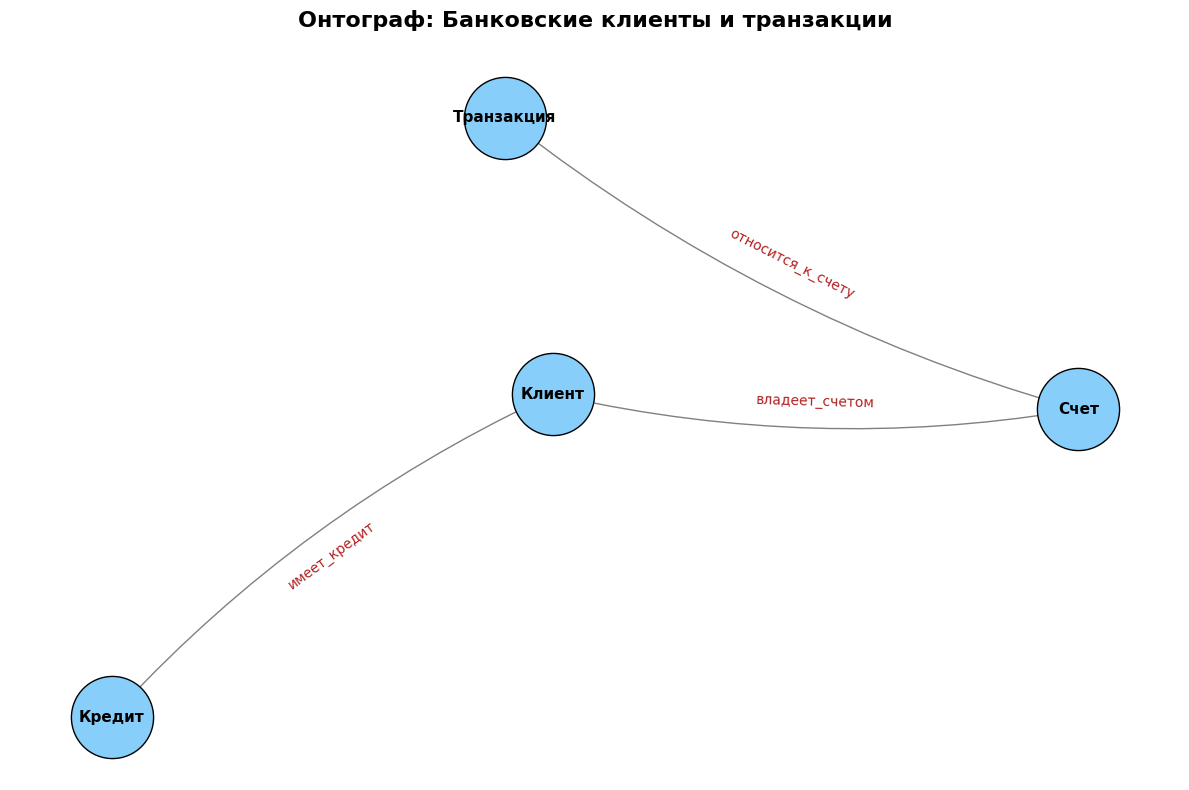

In [9]:
from owlready2 import *
import networkx as nx
import matplotlib.pyplot as plt


onto = get_ontology("bank_ontology_.owl").load()


G = nx.DiGraph()


for cls in list(onto.classes()):
    # Добавляем класс как узел
    G.add_node(cls.name)
    
    for prop in list(onto.object_properties()):
        if cls in prop.domain:
         
            for target in prop.range:
                
                if hasattr(target, 'name'):
                    G.add_edge(cls.name, target.name, label=prop.name)

plt.figure(figsize=(12, 8)) 


pos = nx.spring_layout(G, seed=42, k=1.5)


nx.draw_networkx_nodes(G, pos, node_size=3500, node_color='#87CEFA', edgecolors='black')


nx.draw_networkx_labels(G, pos, font_size=11, font_weight="bold")


nx.draw_networkx_edges(G, pos, arrows=True, arrowsize=25, edge_color='gray', connectionstyle='arc3,rad=0.1')


edge_labels = {(u, v): d['label'] for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='#B22222', font_size=10)


plt.title("Онтограф: Банковские клиенты и транзакции", fontsize=16, fontweight='bold', pad=20)
plt.axis("off")
plt.tight_layout()


plt.show()